# **Projet 4 - Analyse des causes d'attrition au sein d'une ESN**

> - Réaliser une analyse exploratoire des données afin d'identifier les principales tendances et différences entre les employés.
> - Identifier les facteurs potentiellement associés à l'attrition des employés.
> - Préparer et nettoyer les données afin de construire un jeu de données centralisé et exploitable pour la modélisation.
> - Comparer plusieurs modèles de classification supervisée afin de prédire le risque d'attrition.
> - Identifier les variables ayant le plus d'influence sur l'attrition des employés.

## **Contexte**

> -  Une entreprise de services du numérique (ESN) souhaite mieux comprendre les facteurs associés au départ de ses employés.
> - L'entreprise dispose de plusieurs fichiers de données contenant des informations sur les employés, leur situation professionnelle et leurs caractéristiques.
> - L'objectif est d'explorer et de croiser ces données afin d'identifier les principales tendances associées à l'attrition et de préparer les données pour la modélisation prédictive.

 ## **Objectif**
> - Identifier les principaux facteurs associés à l'attrition des employés afin de mieux comprendre les causes de départ au sein de l'ESN et de construire un modèle permettant de prédire le risque d'attrition.

## **Objectifs Data**

> -  **Comprendre les jeux de données :** analyser la structure, les types de variables, les valeurs manquantes, les doublons et la qualité des données.
> -  **Nettoyer et préparer les données :** identifier et traiter les incohérences, nettoyer les variables quantitatives et qualitatives, et réaliser les jointures nécessaires entre les différents fichiers.
> -  **Réaliser une analyse exploratoire (EDA) :** identifier les distributions, les différences entre les employés et les facteurs potentiellement associés à l'attrition.
> -  **Construire et comparer plusieurs modèles de classification :** prédire l'attrition des employés et sélectionner le modèle le plus performant.
> -  **Optimiser et interpréter le modèle retenu :** rechercher les meilleurs hyperparamètres, évaluer les performances du modèle et identifier les variables ayant le plus d'influence sur l'attrition.

## **ÉTAPE 1 - Analyse exploratoire et Nettoyage**

#### **Importation des librairies**

In [1]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


#### **Importation des jeux des données**

In [2]:
# importation des fichiers csv 

df_evaluation = pd.read_csv("../data/raw/extrait_eval.csv")
df_sirh = pd.read_csv("../data/raw/extrait_sirh.csv")
df_sondage = pd.read_csv("../data/raw/extrait_sondage.csv")

print ("Importation des fichiers csv OK")

Importation des fichiers csv OK


### **Analyse exploratoire"**

#### **Base `df_evaluation`**

##### **Dimensions**

In [3]:
print("La base de données contient", df_evaluation.shape[0], "lignes et", df_evaluation.shape[1], "colonnes.")

La base de données contient 1470 lignes et 10 colonnes.


In [4]:
df_evaluation.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [5]:
#check the columns names

df_evaluation.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente'],
      dtype='str')

##### **Statistiques descriptives**

Commencer par des statistiques descriptives simples sur chacun des trois fichiers.

In [6]:
df_evaluation.describe().round(1)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,2.7,2.7,2.1,2.7,2.7,2.8,3.2
std,1.1,0.7,1.1,1.1,1.1,0.7,0.4
min,1.0,1.0,1.0,1.0,1.0,1.0,3.0
25%,2.0,2.0,1.0,2.0,2.0,2.0,3.0
50%,3.0,3.0,2.0,3.0,3.0,3.0,3.0
75%,4.0,3.0,3.0,4.0,4.0,3.0,3.0
max,4.0,4.0,5.0,4.0,4.0,4.0,4.0


> - La base `df_evaluation` portent sur **1 470 lignes** pour chacune des variables analysées.
>
>   - Les variables de satisfaction présentent des moyennes comprises entre **2,7 et 2,8**, avec des valeurs allant de **1 à 4**.
>   - `note_evaluation_precedente` présente une moyenne de **2,7**, avec des valeurs entre **1 et 4**.
>   - `niveau_hierarchique_poste` présente une moyenne de **2,1**, avec des valeurs entre **1 et 5**.
>   - `note_evaluation_actuelle` présente une moyenne de **3,2**, avec des valeurs entre **3 et 4**.
>   - `augmentation_salaire_precedente` présente une moyenne de **15,2 %**, avec des valeurs entre **11 % et 25 %**.
>   - Les écarts-types des variables de satisfaction sont d'environ **1,1**, tandis que `note_evaluation_actuelle` présente une dispersion plus faible (**0,4**).

##### **Infos génerales**

In [7]:
df_evaluation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB


##### **Doublons**

In [8]:
df_evaluation.duplicated().sum()

np.int64(0)

##### **Valeurs Manquantes**

In [9]:
# Calcul des valeurs manquantes par colonne

df_evaluation.isna().sum()

satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
eval_number                                  0
note_evaluation_actuelle                     0
heure_supplementaires                        0
augementation_salaire_precedente             0
dtype: int64

##### **Types des données**

In [10]:
# Types de données

df_evaluation.dtypes

satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_hierarchique_poste                    int64
satisfaction_employee_nature_travail         int64
satisfaction_employee_equipe                 int64
satisfaction_employee_equilibre_pro_perso    int64
eval_number                                    str
note_evaluation_actuelle                     int64
heure_supplementaires                          str
augementation_salaire_precedente               str
dtype: object

##### **Valeurs uniques pour chaque colonne**

In [11]:
# Affichage des valeurs uniques pour chaque colonne

for col in df_evaluation.columns:
    print(f"\n--- {col} ---")
    print(df_evaluation[col].unique())


--- satisfaction_employee_environnement ---
[2 3 4 1]

--- note_evaluation_precedente ---
[3 2 4 1]

--- niveau_hierarchique_poste ---
[2 1 3 4 5]

--- satisfaction_employee_nature_travail ---
[4 2 3 1]

--- satisfaction_employee_equipe ---
[1 4 2 3]

--- satisfaction_employee_equilibre_pro_perso ---
[1 3 2 4]

--- eval_number ---
<StringArray>
[   'E_1',    'E_2',    'E_4',    'E_5',    'E_7',    'E_8',   'E_10',
   'E_11',   'E_12',   'E_13',
 ...
 'E_2054', 'E_2055', 'E_2056', 'E_2057', 'E_2060', 'E_2061', 'E_2062',
 'E_2064', 'E_2065', 'E_2068']
Length: 1470, dtype: str

--- note_evaluation_actuelle ---
[3 4]

--- heure_supplementaires ---
<StringArray>
['Oui', 'Non']
Length: 2, dtype: str

--- augementation_salaire_precedente ---
<StringArray>
['11 %', '23 %', '15 %', '12 %', '13 %', '20 %', '22 %', '21 %', '17 %',
 '14 %', '16 %', '18 %', '19 %', '24 %', '25 %']
Length: 15, dtype: str


##### **Vérification des colonnes**

Prendre l’habitude d’utiliser la méthode .apply() de Pandas pour nettoyer vos colonnes.

In [12]:
# Conversion de la colonne 'augementation_salaire_precedente' en int64
# en supprimant le symbole '%' et les espaces

df_evaluation["augementation_salaire_precedente"] = (
    df_evaluation["augementation_salaire_precedente"]
    .apply(lambda x: int(x.replace("%", "").strip()))
)

print("Conversion de la colonne 'augementation_salaire_precedente' en int64 OK")

Conversion de la colonne 'augementation_salaire_precedente' en int64 OK


> -  La colonne `augementation_salaire_precedente` était de type string. Nous l'avons donc convertie en type `float64` afin de pouvoir l'utiliser comme variable quantitative.

##### **Identification des colonnes quantitatives et qualitatives** 

Identifier et nettoyer les colonnes qui correspondent à des informations quantitatives ou qualitatives.

In [13]:
# Classification des variables quantitatives et qualitatives

classification_evaluation = pd.DataFrame({
    "Variable": [
        "satisfaction_employee_environnement",
        "note_evaluation_precedente",
        "niveau_hierarchique_poste",
        "satisfaction_employee_nature_travail",
        "satisfaction_employee_equipe",
        "satisfaction_employee_equilibre_pro_perso",
        "eval_number",
        "note_evaluation_actuelle",
        "heure_supplementaires",
        "augmentation_salaire_precedente"
    ],
    "Type de donnée": [
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "string",
        "int64",
        "string",
        "int64"
    ],
    "Nature": [
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Identifiant",
        "Qualitative",
        "Qualitative",
        "Quantitative"
    ]
})

classification_evaluation

,Variable,Type de donnée,Nature
0,satisfaction_employee_environnement,int64,Qualitative
1,note_evaluation_precedente,int64,Qualitative
2,niveau_hierarchique_poste,int64,Qualitative
3,satisfaction_employee_nature_travail,int64,Qualitative
4,satisfaction_employee_equipe,int64,Qualitative
5,satisfaction_employee_equilibre_pro_perso,int64,Qualitative
6,eval_number,string,Identifiant
7,note_evaluation_actuelle,int64,Qualitative
8,heure_supplementaires,string,Qualitative
9,augmentation_salaire_precedente,int64,Quantitative


- > **Évaluation :** la base contient 1 colonne identifiante (`eval_number`), 1 colonne quantitative (`augmentation_salaire_precedente`) et 8 colonnes qualitatives.

In [14]:
print("La base de données contient", df_evaluation.shape[0], "lignes et", df_evaluation.shape[1], "colonnes.")

La base de données contient 1470 lignes et 10 colonnes.


#### **Base `df_sirh`**

##### **Dimensions**

In [15]:
print("La base de données contient", df_sirh.shape[0], "lignes et", df_sirh.shape[1], "colonnes.")

La base de données contient 1470 lignes et 12 colonnes.


In [16]:
df_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [17]:
#check the columns names

df_sirh.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel'],
      dtype='str')

##### **Statistiques descriptives**

Commencer par des statistiques descriptives simples sur chacun des trois fichiers.

In [18]:
df_sirh.describe().round(1)

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,1024.9,36.9,6502.9,2.7,80.0,11.3,7.0,4.2
std,602.0,9.1,4708.0,2.5,0.0,7.8,6.1,3.6
min,1.0,18.0,1009.0,0.0,80.0,0.0,0.0,0.0
25%,491.2,30.0,2911.0,1.0,80.0,6.0,3.0,2.0
50%,1020.5,36.0,4919.0,2.0,80.0,10.0,5.0,3.0
75%,1555.8,43.0,8379.0,4.0,80.0,15.0,9.0,7.0
max,2068.0,60.0,19999.0,9.0,80.0,40.0,40.0,18.0


> - La base `df_sirh` portent sur **1 470 lignes** pour chacune des variables analysées.
>
>   - `age` présente une moyenne de **36,9 ans**, avec des valeurs entre **18 et 60 ans**.
>   - `revenu_mensuel` présente une moyenne de **6 502,9€**, avec des valeurs entre **1 009€ et 19 999€**.
>   - `nombre_experiences_precedentes` présente une moyenne de **2,7**, avec des valeurs entre **0 et 9**.
>   - `nombre_heures_travaillées` présente une valeur constante de **80 heures**, avec un écart-type de **0,0**.
>   - `annee_experience_totale` présente une moyenne de **11,3 ans**, avec des valeurs entre **0 et 40 ans**.
>   - `annees_dans_l_entreprise` présente une moyenne de **7,0 ans**, avec des valeurs entre **0 et 40 ans**.
>   - `annees_dans_le_poste_actuel` présente une moyenne de **4,2 ans**, avec des valeurs entre **0 et 18 ans**.

##### **Infos génerales**

In [19]:
df_sirh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 137.9 KB


##### **Doublons**

In [20]:
df_sirh.duplicated().sum()

np.int64(0)

##### **Valeurs Manquantes**

In [21]:
# Calcul des valeurs manquantes par colonne

df_sirh.isna().sum()

id_employee                       0
age                               0
genre                             0
revenu_mensuel                    0
statut_marital                    0
departement                       0
poste                             0
nombre_experiences_precedentes    0
nombre_heures_travailless         0
annee_experience_totale           0
annees_dans_l_entreprise          0
annees_dans_le_poste_actuel       0
dtype: int64

##### **Types des données**

In [22]:
# Types de données

df_sirh.dtypes

id_employee                       int64
age                               int64
genre                               str
revenu_mensuel                    int64
statut_marital                      str
departement                         str
poste                               str
nombre_experiences_precedentes    int64
nombre_heures_travailless         int64
annee_experience_totale           int64
annees_dans_l_entreprise          int64
annees_dans_le_poste_actuel       int64
dtype: object

##### **Valeurs uniques pour chaque colonne**

In [23]:
# Affichage des valeurs uniques pour chaque colonne

for col in df_sirh.columns:
    print(f"\n--- {col} ---")
    print(df_sirh[col].unique())


--- id_employee ---
[   1    2    4 ... 2064 2065 2068]

--- age ---
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]

--- genre ---
<StringArray>
['F', 'M']
Length: 2, dtype: str

--- revenu_mensuel ---
[5993 5130 2090 ... 9991 5390 4404]

--- statut_marital ---
<StringArray>
['Célibataire', 'Marié(e)', 'Divorcé(e)']
Length: 3, dtype: str

--- departement ---
<StringArray>
['Commercial', 'Consulting', 'Ressources Humaines']
Length: 3, dtype: str

--- poste ---
<StringArray>
[       'Cadre Commercial',  'Assistant de Direction',
              'Consultant',               'Tech Lead',
                 'Manager',          'Senior Manager',
 'Représentant Commercial',     'Directeur Technique',
     'Ressources Humaines']
Length: 9, dtype: str

--- nombre_experiences_precedentes ---
[8 1 6 9 0 4 5 2 7 3]

--- nombre_heures_travailless ---
[80]

--- annee_experience_totale ---
[ 8 10  7  6 12  1 17  5  3 31 

> - L'analyse des types de données et des valeurs uniques montre que les variables de la base `df_evaluation` sont cohérentes avec leur nature.
> - Aucune autre transformation des types de données n'est nécessaire pour cette base.

##### **Identification des colonnes quantitatives et qualitatives**

In [24]:
# Classification des variables Quantiatives et Qualitatives

classification_sirh = pd.DataFrame({
    "Variable": [
        "id_employee",
        "age",
        "genre",
        "revenu_mensuel",
        "statut_marital",
        "departement",
        "poste",
        "nombre_experiences_precedentes",
        "annee_experience_totale",
        "annees_dans_l_entreprise",
        "annees_dans_le_poste_actuel"
    ],
    "Type de donnée": [
        "int64",
        "int64",
        "string",
        "int64",
        "string",
        "string",
        "string",
        "int64",
        "int64",
        "int64",
        "int64"
    ],
    "Nature": [
        "Identifiant",
        "Quantitative",
        "Qualitative",
        "Quantitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative"
    ]
})

classification_sirh

,Variable,Type de donnée,Nature
0,id_employee,int64,Identifiant
1,age,int64,Quantitative
2,genre,string,Qualitative
3,revenu_mensuel,int64,Quantitative
4,statut_marital,string,Qualitative
5,departement,string,Qualitative
6,poste,string,Qualitative
7,nombre_experiences_precedentes,int64,Quantitative
8,annee_experience_totale,int64,Quantitative
9,annees_dans_l_entreprise,int64,Quantitative


> - **SisRH :** 1 colonne identifiant ('id_employee'), 6 colonnes quantitatives et 4 colonnes qualitatives.

In [25]:
print("La base de données contient", df_sirh.shape[0], "lignes et", df_sirh.shape[1], "colonnes.")

La base de données contient 1470 lignes et 12 colonnes.


#### **Base `df_sondage`**

##### **Dimensions**

In [26]:
print("La base de données contient", df_sondage.shape[0], "lignes et", df_sondage.shape[1], "colonnes.")

La base de données contient 1470 lignes et 12 colonnes.


In [27]:
df_sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [28]:
#check the columns names

df_sondage.columns

Index(['a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'code_sondage', 'distance_domicile_travail', 'niveau_education',
       'domaine_etude', 'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='str')

##### **Statistiques descriptives**

Commencer par des statistiques descriptives simples sur chacun des trois fichiers.

In [29]:
df_sondage.describe().round(1)

,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,0.8,2.8,1.0,1024.9,9.2,2.9,2.2,4.1
std,0.9,1.3,0.0,602.0,8.1,1.0,3.2,3.6
min,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
25%,0.0,2.0,1.0,491.2,2.0,2.0,0.0,2.0
50%,1.0,3.0,1.0,1020.5,7.0,3.0,1.0,3.0
75%,1.0,3.0,1.0,1555.8,14.0,4.0,3.0,7.0
max,3.0,6.0,1.0,2068.0,29.0,5.0,15.0,17.0


> - La base `df_sondage` portent sur **1 470 lignes** pour chacune des variables analysées.
>
>   - `nombre_participation_pee` présente une moyenne de **0,8**, avec des valeurs entre **0 et 3**.
>   - `nb_formations_suivies` présente une moyenne de **2,8**, avec des valeurs entre **0 et 6**.
>   - `distance_domicile_travail` présente une moyenne de **9,2**, avec des valeurs entre **1 et 29**.
>   - `niveau_education` présente une moyenne de **2,9**, avec des valeurs entre **1 et 5**.
>   - `annees_depuis_la_derniere_promotion` présente une moyenne de **2,2 ans**, avec des valeurs entre **0 et 15 ans**.
>   - `annes_sous_responsable_actuel` présente une moyenne de **4,1 ans**, avec des valeurs entre **0 et 17 ans**.

>   - Les variables présentent des niveaux de dispersion différents, avec des écarts-types compris entre **0,9 et 8,1**.

##### **Infos génerales**

In [30]:
df_sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

##### **Doublons**

In [31]:
df_sondage.duplicated().sum()

np.int64(0)

##### **Valeurs Manquantes**

In [32]:
# Calcul des valeurs manquantes par colonne

df_sondage.isna().sum()

a_quitte_l_entreprise                  0
nombre_participation_pee               0
nb_formations_suivies                  0
nombre_employee_sous_responsabilite    0
code_sondage                           0
distance_domicile_travail              0
niveau_education                       0
domaine_etude                          0
ayant_enfants                          0
frequence_deplacement                  0
annees_depuis_la_derniere_promotion    0
annes_sous_responsable_actuel          0
dtype: int64

##### **Types des données**

In [33]:
# Types de données

df_sondage.dtypes

a_quitte_l_entreprise                    str
nombre_participation_pee               int64
nb_formations_suivies                  int64
nombre_employee_sous_responsabilite    int64
code_sondage                           int64
distance_domicile_travail              int64
niveau_education                       int64
domaine_etude                            str
ayant_enfants                            str
frequence_deplacement                    str
annees_depuis_la_derniere_promotion    int64
annes_sous_responsable_actuel          int64
dtype: object

##### **Valeurs uniques pour chaque colonne**

In [34]:
# Affichage des valeurs uniques pour chaque colonne

for col in df_sondage.columns:
    print(f"\n--- {col} ---")
    print(df_sondage[col].unique())


--- a_quitte_l_entreprise ---
<StringArray>
['Oui', 'Non']
Length: 2, dtype: str

--- nombre_participation_pee ---
[0 1 3 2]

--- nb_formations_suivies ---
[0 3 2 5 1 4 6]

--- nombre_employee_sous_responsabilite ---
[1]

--- code_sondage ---
[   1    2    4 ... 2064 2065 2068]

--- distance_domicile_travail ---
[ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25 12 18 29 22
 14 20 28 17 13]

--- niveau_education ---
[2 1 4 3 5]

--- domaine_etude ---
<StringArray>
[          'Infra & Cloud',                   'Autre',
 'Transformation Digitale',               'Marketing',
         'Entrepreunariat',     'Ressources Humaines']
Length: 6, dtype: str

--- ayant_enfants ---
<StringArray>
['Y']
Length: 1, dtype: str

--- frequence_deplacement ---
<StringArray>
['Occasionnel', 'Frequent', 'Aucun']
Length: 3, dtype: str

--- annees_depuis_la_derniere_promotion ---
[ 0  1  3  2  7  4  8  6  5 15  9 13 12 10 11 14]

--- annes_sous_responsable_actuel ---
[ 5  7  0  2  6  8  3 11 17  1

##### **Identification des colonnes quantitatives et qualitatives**

In [35]:
#check the columns names

df_sondage.columns

Index(['a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'code_sondage', 'distance_domicile_travail', 'niveau_education',
       'domaine_etude', 'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='str')

In [36]:
classification_sondage = pd.DataFrame({
    "Variable": [
        "a_quitte_l_entreprise",
        "nombre_participation_pee",
        "nb_formations_suivies",
        "code_sondage",
        "distance_domicile_travail",
        "niveau_education",
        "domaine_etude",
        "frequence_deplacement",
        "annees_depuis_la_derniere_promotion",
        "annees_sous_responsable_actuel"
    ],
    "Nature": [
        "Qualitative",
        "Quantitative",
        "Quantitative",
        "Identifiant",
        "Quantitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Quantitative",
        "Quantitative"
    ]
})

classification_sondage

,Variable,Nature
0,a_quitte_l_entreprise,Qualitative
1,nombre_participation_pee,Quantitative
2,nb_formations_suivies,Quantitative
3,code_sondage,Identifiant
4,distance_domicile_travail,Quantitative
5,niveau_education,Qualitative
6,domaine_etude,Qualitative
7,frequence_deplacement,Qualitative
8,annees_depuis_la_derniere_promotion,Quantitative
9,annees_sous_responsable_actuel,Quantitative


> - **Sondage :** 1 colonne identifiant ('code_sondage'), 5 colonnes quantitatives et 4 colonnes qualitatives.

In [37]:
print("La base de données contient", df_evaluation.shape[0], "lignes et", df_evaluation.shape[1], "colonnes.")

La base de données contient 1470 lignes et 10 colonnes.


#### **Conclusions de l'analyse exploratoire**

> - **Dimensions des bases :**
>
>   - `df_evaluation` contient **1 470 lignes et 9 colonnes**. 1 colonne identifiante (`eval_number`), 1 colonne quantitative (`augmentation_salaire_precedente`) et 7 colonnes qualitatives.
>   - `df_sirh` contient **1 470 lignes et 11 colonnes**: 1 colonne identifiant (`id_employee`), 6 colonnes quantitatives et 4 colonnes qualitatives.
>   - `df_sondage` contient **1 470 lignes et 10 colonnes** : 1 colonne identifiant (`code_sondage`), 5 colonnes quantitatives et 4 colonnes qualitatives.
>
> - **Qualité des données :**
>   - Aucune des trois bases ne contient de **doublons complets**.
>   - Aucune des trois bases ne contient de **valeurs manquantes**.
>   - `df_sondage` : Les colonnes `nombre_employee_sous_responsabilite` et  `ayant_enfant` ont été supprimées
>
> - **Identification des employés et des évaluations :**
>   - `df_sirh` contient la variable `id_employee`, avec **1 470 valeurs uniques**.
>   - `df_sondage` contient la variable `code_sondage`, avec **1 470 valeurs uniques**.
>   - `df_evaluation` contient la variable `eval_number`, utilisée pour identifier les évaluations.
  
> - Ces éléments constituent une première vérification de la structure et de la qualité des trois fichiers avant d'identifier les clés permettant de réaliser les jointures.

### **Nettoyage des Données**

##### **Suppréssion des colonnes inutilles**

In [38]:
# Suppression de la colonne sans variabilité 

df_sirh = df_sirh.drop(columns=["nombre_heures_travailless"])

print("Suppression de la colonne 'nombre_heures_travailless' OK")

Suppression de la colonne 'nombre_heures_travailless' OK


> - Les colonnes `nombre_employee_sous_responsabilite` et  `ayant_enfant` ne présente aucune variabilité pour l'ensemble des employés. Elles seront donc supprimées.

In [39]:
# Suppression de la colonne sans variabilité

df_sondage = df_sondage.drop(columns=["nombre_employee_sous_responsabilite",
        "ayant_enfants"])

print ("Suppression de la colonne 'nombre_employee_sous_responsabilite' OK")
print ("Suppression de la colonne 'ayant_enfants' OK")

Suppression de la colonne 'nombre_employee_sous_responsabilite' OK
Suppression de la colonne 'ayant_enfants' OK


> - Les colonnes `nombre_employee_sous_responsabilite` et `ayant_enfants` ont été supprimées car elles sont constantes dans la population étudiée. Une variable sans variabilité n'apporte aucune information discriminante pour l'analyse.

#### **Nettoyage des clés de jointure**

##### **Identification des colonnes similaires**

Identifier les colonnes permettant de réaliser des jointures entre les 3 fichiers.

> - Les colonnes `id_employee`, `code_sondage` et `eval_number` semblent correspondre au même identifiant employé, mais `eval_number` contient le préfixe `E_`.

In [40]:
df_sirh["id_employee"].head(5)

0    1
1    2
2    4
3    5
4    7
Name: id_employee, dtype: int64

In [41]:
df_evaluation["eval_number"].head(5)

0    E_1
1    E_2
2    E_4
3    E_5
4    E_7
Name: eval_number, dtype: str

In [42]:
df_sondage["code_sondage"].head(5)

0    1
1    2
2    4
3    5
4    7
Name: code_sondage, dtype: int64

> - **Analyse :** 'eval_number' contient le même identifiant que les autres bases, mais avec le préfixe E_. Nous allons transformer standartiser la colonne et convertir le type pour Int64

##### **Harmonisation de "eval_number"**

In [43]:
# Nettoyage de la clé de jointure

df_evaluation["eval_number"] = (
    df_evaluation["eval_number"]
    .str.replace("E_", "", regex=False)
    .astype("int64")
)

print("Nettoyage de la clé 'eval_number' OK")

Nettoyage de la clé 'eval_number' OK


In [44]:
#verification de la clé de jointure

df_evaluation["eval_number"].head()

0    1
1    2
2    4
3    5
4    7
Name: eval_number, dtype: int64

##### **Choix du type de jointure**

Déterminer quel type de jointure sera le plus adapté pour rapprocher les fichiers (left, inner etc.).

> - **Analyse :** Nous allons confirmer que les 1 470 identifiants sont exactement les mêmes dans les trois bases de données.

In [45]:
# vérification du nombre d'identifiants uniques dans chaque DataFrame pour confirmer les clés de jointure

print("id_employee :", df_sirh["id_employee"].nunique())
print("code_sondage :", df_sondage["code_sondage"].nunique())
print("eval_number :", df_evaluation["eval_number"].nunique())

id_employee : 1470
code_sondage : 1470
eval_number : 1470


In [46]:
# Vérification de la correspondance des identifiants entre les trois bases

ids_sirh = set(df_sirh["id_employee"])
ids_sondage = set(df_sondage["code_sondage"])
ids_evaluation = set(df_evaluation["eval_number"])

print("SIRH = Sondage :", ids_sirh == ids_sondage)
print("SIRH = Evaluation :", ids_sirh == ids_evaluation)
print("Sondage = Evaluation :", ids_sondage == ids_evaluation)

SIRH = Sondage : True
SIRH = Evaluation : True
Sondage = Evaluation : True


> - **Objeticf :** garder uniquement les employés présents dans les trois bases.
> - **Choix de la jointure :** une jointure `inner` a été retenue afin de conserver uniquement les employés présents dans les trois bases de données. La vérification préalable des identifiants montre que les trois bases contiennent les mêmes **1 470 employés**, aucune ligne ne sera donc perdue lors des jointures.

### **Création du DataFrame central**

#### **Jointure `df_sirh` + `df_evaluation`**

In [47]:
# Jointure entre df_sirh et df_evaluation

df_central = pd.merge(
    df_sirh,
    df_evaluation,
    left_on="id_employee",
    right_on="eval_number",
    how="inner"
)

print("Jointure df_sirh + df_evaluation OK")
print("Dimensions du DataFrame central :", df_central.shape)

Jointure df_sirh + df_evaluation OK
Dimensions du DataFrame central : (1470, 21)


#### **Ajout `df_sondage`**

In [48]:
# Ajout de df_sondage au DataFrame central

df_central = pd.merge(
    df_central,
    df_sondage,
    left_on="id_employee",
    right_on="code_sondage",
    how="inner"
)

print("Jointure avec df_sondage OK")
print("Dimensions finales du DataFrame central :", df_central.shape)

Jointure avec df_sondage OK
Dimensions finales du DataFrame central : (1470, 31)


#### **Suppression des clés de jointure inutiles**

In [49]:
# Suppression des clés de jointure devenues inutiles 'eval_number' et 'code_sondage'

df_central = df_central.drop(columns=["eval_number", "code_sondage"])

print("Suppression des colonnes 'eval_number' et 'code_sondage' OK")
print("Dimensions du DataFrame central :", df_central.shape)

Suppression des colonnes 'eval_number' et 'code_sondage' OK
Dimensions du DataFrame central : (1470, 29)


#### **Vérification du `df_central`**

In [50]:
print("La base de données `df_central` contient", df_central.shape[0], "lignes et", df_central.shape[1], "colonnes.")

La base de données `df_central` contient 1470 lignes et 29 colonnes.


In [51]:
print("Nombre d'employés dans df_central :", df_central["id_employee"].nunique())

Nombre d'employés dans df_central : 1470


In [52]:
df_central.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'annee_experience_totale', 'annees_dans_l_entreprise',
       'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement',
       'note_evaluation_precedente', 'niveau_hierarchique_poste',
       'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'distance_domicile_travail',
       'niveau_education', 'domaine_etude', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='str')

In [53]:
df_central.dtypes

id_employee                                  int64
age                                          int64
genre                                          str
revenu_mensuel                               int64
statut_marital                                 str
departement                                    str
poste                                          str
nombre_experiences_precedentes               int64
annee_experience_totale                      int64
annees_dans_l_entreprise                     int64
annees_dans_le_poste_actuel                  int64
satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_hierarchique_poste                    int64
satisfaction_employee_nature_travail         int64
satisfaction_employee_equipe                 int64
satisfaction_employee_equilibre_pro_perso    int64
note_evaluation_actuelle                     int64
heure_supplementaires                          str
augementation_salaire_precedent

In [54]:
# Classification des variables du DataFrame central

classification_central = pd.DataFrame({
    "Variable": [
        "id_employee",

        "age",
        "revenu_mensuel",
        "nombre_experiences_precedentes",
        "annee_experience_totale",
        "annees_dans_l_entreprise",
        "annees_dans_le_poste_actuel",
        "augmentation_salaire_precedente",
        "nombre_participation_pee",
        "nb_formations_suivies",
        "distance_domicile_travail",
        "annees_depuis_la_derniere_promotion",
        "annes_sous_responsable_actuel",

        "genre",
        "statut_marital",
        "departement",
        "poste",
        "satisfaction_employee_environnement",
        "note_evaluation_precedente",
        "niveau_hierarchique_poste",
        "satisfaction_employee_nature_travail",
        "satisfaction_employee_equipe",
        "satisfaction_employee_equilibre_pro_perso",
        "note_evaluation_actuelle",
        "heure_supplementaires",
        "a_quitte_l_entreprise",
        "niveau_education",
        "domaine_etude",
        "frequence_deplacement"
    ],

    "Type de donnée": [
        "int64",

        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",

        "string",
        "string",
        "string",
        "string",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "int64",
        "string",
        "string",
        "int64",
        "string",
        "string"
    ],

    "Nature": [
        "Identifiant",

        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",
        "Quantitative",

        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative",
        "Qualitative"
    ],

    "Description": [
        "Identifiant unique de l'employé",

        "Âge de l'employé",
        "Revenu mensuel de l'employé",
        "Nombre d'expériences professionnelles précédentes",
        "Nombre total d'années d'expérience professionnelle",
        "Nombre d'années passées dans l'entreprise",
        "Nombre d'années dans le poste actuel",
        "Pourcentage de la précédente augmentation salariale",
        "Nombre de participations au Plan d'Épargne Entreprise (PEE)",
        "Nombre de formations suivies",
        "Distance entre le domicile et le lieu de travail",
        "Nombre d'années depuis la dernière promotion",
        "Nombre d'années sous la responsabilité du responsable actuel",

        "Genre de l'employé",
        "Statut marital de l'employé",
        "Département dans lequel travaille l'employé",
        "Poste occupé par l'employé",
        "Satisfaction concernant l'environnement de travail",
        "Note de l'évaluation précédente",
        "Niveau hiérarchique du poste",
        "Satisfaction concernant la nature du travail",
        "Satisfaction concernant l'équipe",
        "Satisfaction entre l'équilibre professionnelle et personnelle",
        "Note de l'évaluation actuelle",
        "Indique si l'employé effectue des heures supplémentaires",
        "Indique si l'employé a quitté l'entreprise",
        "Niveau d'éducation de l'employé",
        "Domaine d'étude de l'employé",
        "Fréquence des déplacements professionnels"
    ]
})

classification_central

,Variable,Type de donnée,Nature,Description
0,id_employee,int64,Identifiant,Identifiant unique de l'employé
1,age,int64,Quantitative,Âge de l'employé
2,revenu_mensuel,int64,Quantitative,Revenu mensuel de l'employé
3,nombre_experiences_precedentes,int64,Quantitative,Nombre d'expériences professionnelles précédentes
4,annee_experience_totale,int64,Quantitative,Nombre total d'années d'expérience professionn...
5,annees_dans_l_entreprise,int64,Quantitative,Nombre d'années passées dans l'entreprise
6,annees_dans_le_poste_actuel,int64,Quantitative,Nombre d'années dans le poste actuel
7,augmentation_salaire_precedente,int64,Quantitative,Pourcentage de la précédente augmentation sala...
8,nombre_participation_pee,int64,Quantitative,Nombre de participations au Plan d'Épargne Ent...
9,nb_formations_suivies,int64,Quantitative,Nombre de formations suivies


In [55]:
# Exportation du DataFrame central au format CSV

df_central.to_csv(
    "df_central.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exportation de 'df_central' en CSV OK")

Exportation de 'df_central' en CSV OK


#### **Conclusions du DataFrame Central**

> - `df_central` contient **1 470 lignes et 29 variables**.
>
> - La base contient **1 variable identifiante** : `id_employee`.
>
>   - **12 variables quantitatives** ont été identifiées, correspondant notamment à l'âge, au revenu mensuel, à l'expérience professionnelle, aux années d'ancienneté et à la distance domicile-travail.
>
>   - **16 variables qualitatives** ont été identifiées, notamment les informations sociodémographiques, professionnelles, les niveaux de satisfaction et les variables liées à l'évaluation et au départ de l'entreprise.
>
>   - La classification a été réalisée en tenant compte de la **nature réelle des variables**, indépendamment de leur type de donnée (`int64`, `string`, etc.). Ainsi, certaines variables stockées sous forme numérique ont été classées comme qualitatives lorsqu'elles représentent des catégories ou des niveaux.

### **Analyse de l'attrition**

#### **Analyse qualitative**

##### **Distribution de l'attrition (Turnover)**

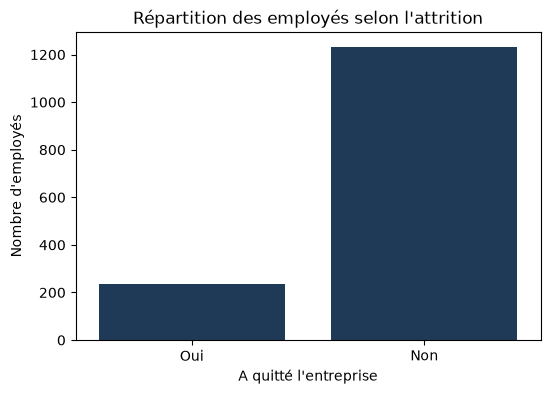

In [56]:
# Visualisation de la répartition des employés selon l'attrition

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    color="#163A5F"
)

plt.title("Répartition des employés selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Nombre d'employés")

plt.show()

<Figure size 600x600 with 0 Axes>

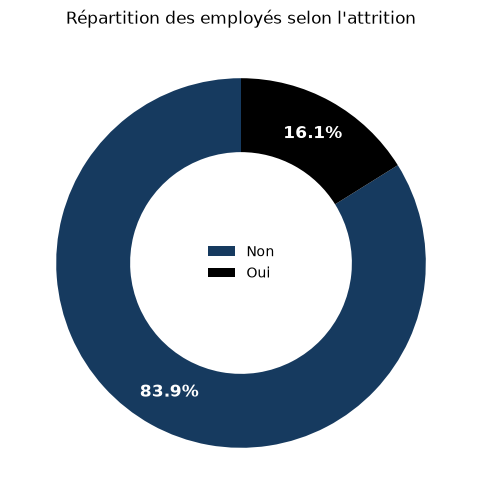

In [57]:
# Visualisation de la répartition des employés selon l'attrition

plt.figure(figsize=(6, 6))

counts = df_central["a_quitte_l_entreprise"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

wedges, _ = ax.pie(
    counts,
    labels=None,
    startangle=90,
    colors=["#163A5F", "#000000"],
    wedgeprops=dict(width=0.4)
)

# Ajouter les pourcentages en blanc au centre de chaque section
total = counts.sum()

for wedge, count in zip(wedges, counts):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.8 * np.cos(np.deg2rad(angle))
    y = 0.8 * np.sin(np.deg2rad(angle))

    ax.text(
        x,
        y,
        f"{count / total:.1%}",
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

# Légende au centre du donut
ax.legend(
    wedges,
    counts.index,
    loc="center",
    frameon=False
)

ax.set_title("Répartition des employés selon l'attrition")

plt.show()

##### **Attrition selon les heures supplémentaires**

<Figure size 600x400 with 0 Axes>

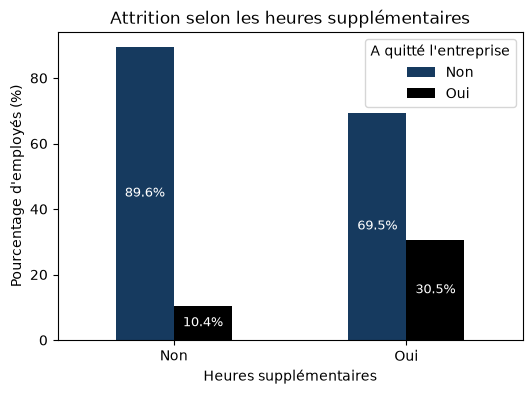

In [58]:
# Attrition selon les heures supplémentaires

plt.figure(figsize=(6, 4))

attrition_heures = pd.crosstab(
    df_central["heure_supplementaires"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

ax = attrition_heures.plot(
    kind="bar",
    color=["#163A5F", "#000000"],
    figsize=(6, 4)
)

plt.title("Attrition selon les heures supplémentaires")
plt.xlabel("Heures supplémentaires")
plt.ylabel("Pourcentage d'employés (%)")

plt.legend(title="A quitté l'entreprise")
plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.show()

> - **Analyse :** Le taux d'attrition est donc environ **3 fois plus élevé** chez les employés concernés par les heures supplémentaires. Cette observation met en évidence une **association** entre les heures supplémentaires et l'attrition, sans permettre de conclure à un lien de causalité.

##### **Attrition selon la fréquence des déplacements**

<Figure size 700x400 with 0 Axes>

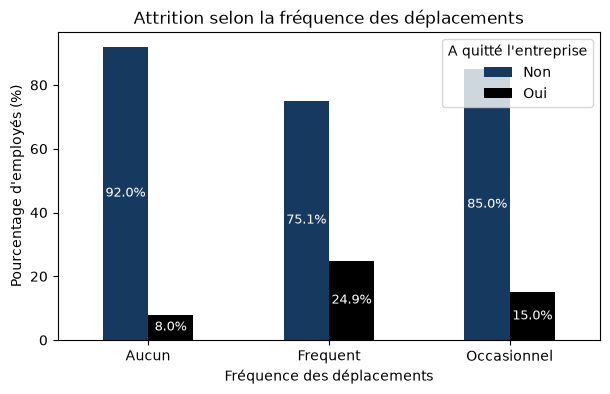

In [59]:
# Attrition selon la fréquence des déplacements

plt.figure(figsize=(7, 4))

attrition_deplacement = pd.crosstab(
    df_central["frequence_deplacement"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

ax = attrition_deplacement.plot(
    kind="bar",
    color=["#163A5F", "#000000"],
    figsize=(7, 4)
)

plt.title("Attrition selon la fréquence des déplacements")
plt.xlabel("Fréquence des déplacements")
plt.ylabel("Pourcentage d'employés (%)")

plt.legend(title="A quitté l'entreprise")
plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.show()

> - **Analyse :** Le taux d'attrition atteint **24,9 %** chez les employés effectuant des déplacements fréquents, contre **8,0 %** chez ceux n'effectuant aucun déplacement. Le taux de départ est donc environ **3 fois plus élevé** dans le groupe effectuant des déplacements fréquents.

##### **Attrition selon le département**

<Figure size 700x400 with 0 Axes>

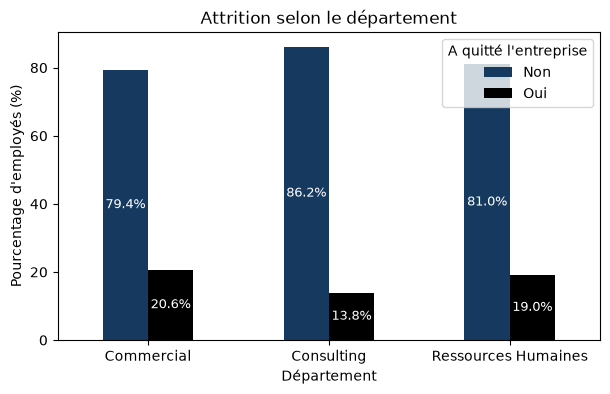

In [60]:
# Attrition selon le département

plt.figure(figsize=(7, 4))

attrition_departement = pd.crosstab(
    df_central["departement"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

ax = attrition_departement.plot(
    kind="bar",
    color=["#163A5F", "#000000"],
    figsize=(7, 4)
)

plt.title("Attrition selon le département")
plt.xlabel("Département")
plt.ylabel("Pourcentage d'employés (%)")

plt.legend(title="A quitté l'entreprise")
plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.show()

> - **Analyse :** Les taux d'attrition restent relativement proches selon les départements, variant de 13,8 % à 20,6 %. Le Commercial présente le taux le plus élevé, mais l'écart observé reste modéré.

##### **Attrition selon le statut marital**

<Figure size 700x400 with 0 Axes>

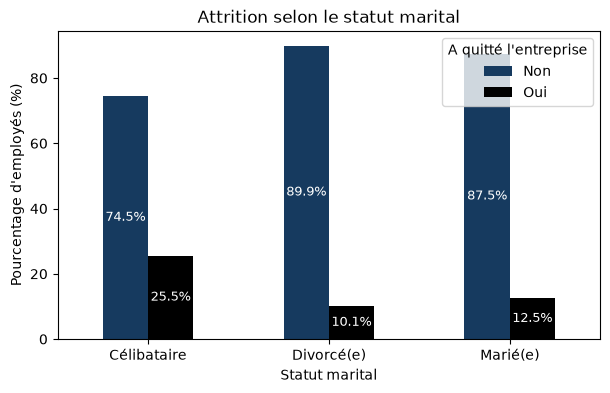

In [61]:
# Attrition selon le statut marital

plt.figure(figsize=(7, 4))

attrition_statut = pd.crosstab(
    df_central["statut_marital"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

ax = attrition_statut.plot(
    kind="bar",
    color=["#163A5F", "#000000"],
    figsize=(7, 4)
)

plt.title("Attrition selon le statut marital")
plt.xlabel("Statut marital")
plt.ylabel("Pourcentage d'employés (%)")

plt.legend(title="A quitté l'entreprise")
plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.show()

> - **Analyse :** Le taux d'attrition est nettement plus élevé chez les employés **célibataires (25,5 %)** que chez les employés **mariés (12,5 %)** ou **divorcés (10,1 %)**. Le taux de départ des employés célibataires est ainsi environ **2 fois plus élevé** que celui des employés mariés.

##### **Attrition selon le genre**

<Figure size 600x400 with 0 Axes>

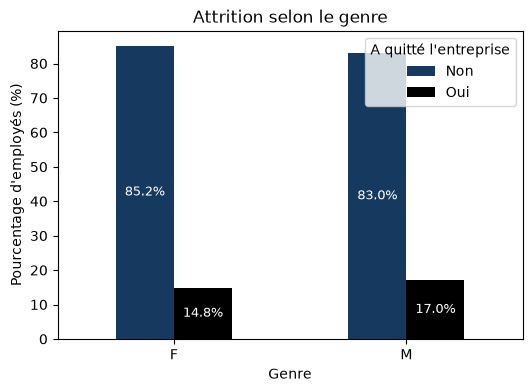

In [62]:
# Attrition selon le genre

plt.figure(figsize=(6, 4))

attrition_genre = pd.crosstab(
    df_central["genre"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

ax = attrition_genre.plot(
    kind="bar",
    color=["#163A5F", "#000000"],
    figsize=(6, 4)
)

plt.title("Attrition selon le genre")
plt.xlabel("Genre")
plt.ylabel("Pourcentage d'employés (%)")

plt.legend(title="A quitté l'entreprise")
plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.show()

> - **Analyse :** Les taux d'attrition sont relativement proches selon le genre : **14,8 % chez les femmes** contre **17,0 % chez les hommes**. La différence observée est faible, ce qui ne met pas en évidence d'association forte entre le genre et l'attrition.

##### **Attrition selon le niveau d'éducation**

<Figure size 700x400 with 0 Axes>

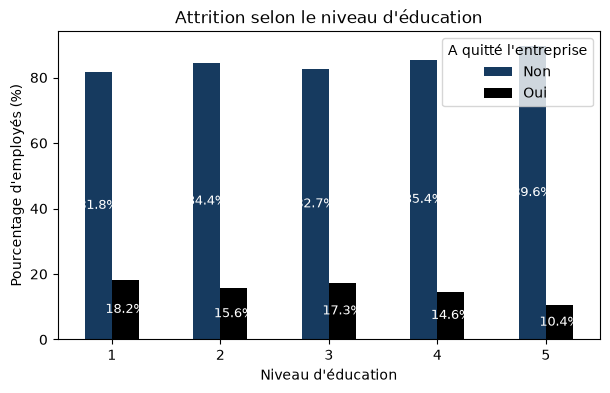

In [63]:
# Attrition selon le niveau d'éducation

plt.figure(figsize=(7, 4))

attrition_education = pd.crosstab(
    df_central["niveau_education"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

ax = attrition_education.plot(
    kind="bar",
    color=["#163A5F", "#000000"],
    figsize=(7, 4)
)

plt.title("Attrition selon le niveau d'éducation")
plt.xlabel("Niveau d'éducation")
plt.ylabel("Pourcentage d'employés (%)")

plt.legend(title="A quitté l'entreprise")
plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

plt.show()

> - **Analyse :** Les taux d'attrition varient de **10,4 % à 18,2 %** selon le niveau d'éducation. Le taux le plus élevé est observé au niveau 1 (**18,2 %**) et le plus faible au niveau 5 (**10,4 %**).

##### **Attrition selon le poste**

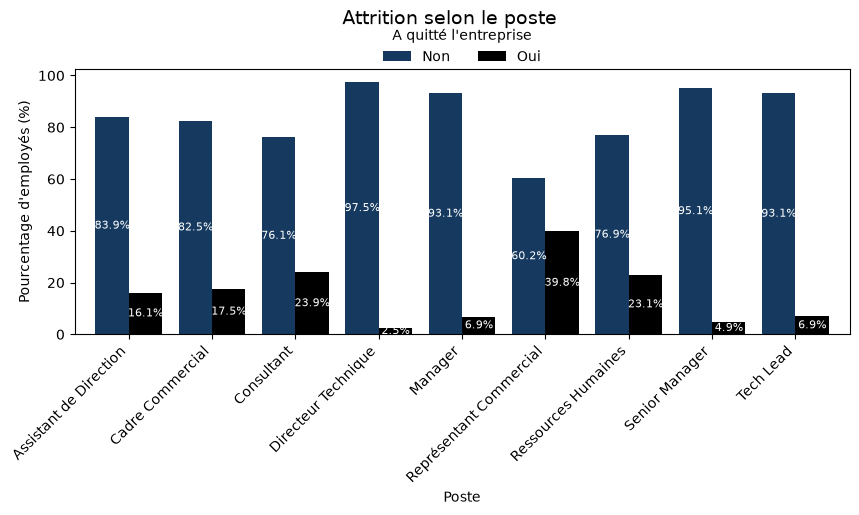

In [64]:
# Attrition selon le poste

fig, ax = plt.subplots(figsize=(10, 5))

attrition_poste = pd.crosstab(
    df_central["poste"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

attrition_poste.plot(
    kind="bar",
    ax=ax,
    color=["#163A5F", "#000000"],
    width=0.8
)

# Titre principal
fig.suptitle(
    "Attrition selon le poste",
    fontsize=14,
    y=0.9
)

# Légende centrée entre le titre et le graphique
ax.legend(
    title="A quitté l'entreprise",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.20),
    ncol=2,
    frameon=False
)

ax.set_xlabel("Poste")
ax.set_ylabel("Pourcentage d'employés (%)")

plt.xticks(rotation=45, ha="right")

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=8
    )

# Espace entre le titre, la légende et le graphique
plt.subplots_adjust(
    top=0.78,
    bottom=0.25
)

plt.show()

> - **Analyse :** Le taux d'attrition varie fortement selon le poste. Les **Représentants Commerciaux présentent le taux d'attrition le plus élevé, avec 39,8 %**, soit près de 4 employés sur 10. À l'inverse, les taux sont particulièrement faibles chez les **Senior Managers (4,9 %)**, les **Managers (6,9 %)** et les **Tech Leads (6,9 %)**. Cette forte différence suggère une association entre le poste occupé et l'attrition.

##### **Satisfaction envers l'environnement de travail**

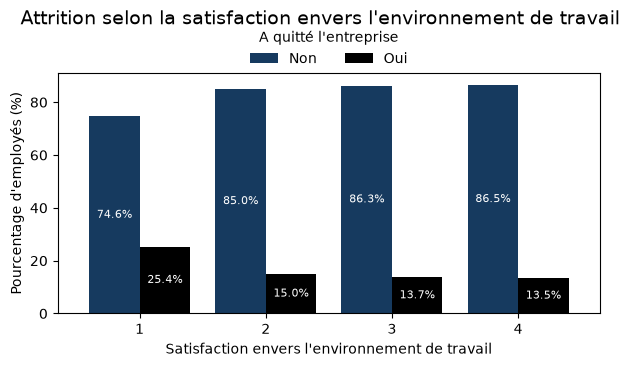

In [65]:
# Attrition selon la satisfaction envers l'environnement de travail

fig, ax = plt.subplots(figsize=(7, 4))

attrition_environnement = pd.crosstab(
    df_central["satisfaction_employee_environnement"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

attrition_environnement.plot(
    kind="bar",
    ax=ax,
    color=["#163A5F", "#000000"],
    width=0.8
)

# Titre principal
fig.suptitle(
    "Attrition selon la satisfaction envers l'environnement de travail",
    fontsize=14,
    y=0.94
)

# Légende centrée entre le titre et le graphique
ax.legend(
    title="A quitté l'entreprise",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.23),
    ncol=2,
    frameon=False
)

ax.set_xlabel("Satisfaction envers l'environnement de travail")
ax.set_ylabel("Pourcentage d'employés (%)")

plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=8
    )

# Espace entre le titre, la légende et le graphique
plt.subplots_adjust(
    top=0.78,
    bottom=0.18
)

plt.show()

> - **Analyse :** Le taux d'attrition est nettement plus élevé chez les employés ayant un niveau de satisfaction de **1 (25,4 %)**. Pour les niveaux de satisfaction de **2 à 4**, les taux restent relativement proches, entre **13,5 % et 15,0 %**. Cette différence suggère une association entre une très faible satisfaction envers l'environnement de travail et l'attrition.

##### **Satisfaction envers la nature du travail**

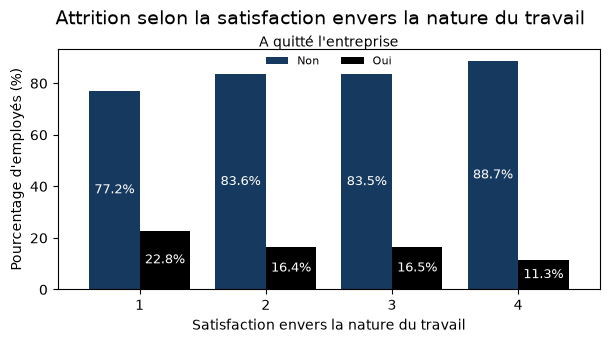

In [66]:
# Attrition selon la satisfaction envers la nature du travail

fig, ax = plt.subplots(figsize=(7, 4))

attrition_nature_travail = pd.crosstab(
    df_central["satisfaction_employee_nature_travail"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

attrition_nature_travail.plot(
    kind="bar",
    ax=ax,
    color=["#163A5F", "#000000"],
    width=0.8
)

# Titre principal
fig.suptitle(
    "Attrition selon la satisfaction envers la nature du travail",
    fontsize=14,
    y=0.90
)

# Légende centrée entre le titre et le graphique
ax.legend(
    title="A quitté l'entreprise",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
    frameon=False,
    fontsize=8
)

ax.set_xlabel("Satisfaction envers la nature du travail")
ax.set_ylabel("Pourcentage d'employés (%)")

plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

# Espace entre le titre, la légende et le graphique
plt.subplots_adjust(
    top=0.80,
    bottom=0.20
)

plt.show()

> - **Analyse :** Le taux d'attrition diminue globalement avec le niveau de satisfaction envers la nature du travail, passant de **22,8 % au niveau 1** à **11,3 % au niveau 4**. Le taux de départ est ainsi **environ deux fois plus élevé** chez les employés les moins satisfaits.

##### **Satisfaction envers l'équipe**

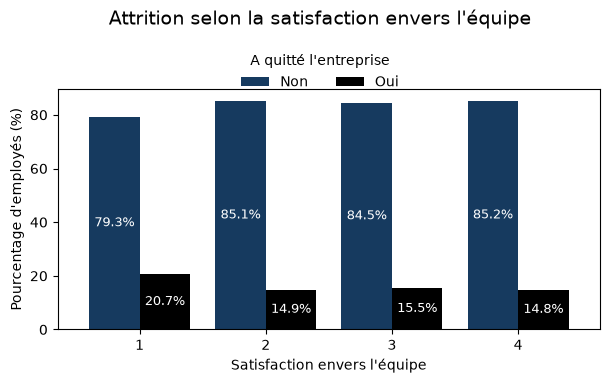

In [67]:
# Attrition selon la satisfaction envers l'équipe

fig, ax = plt.subplots(figsize=(7, 4))

attrition_equipe = pd.crosstab(
    df_central["satisfaction_employee_equipe"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

attrition_equipe.plot(
    kind="bar",
    ax=ax,
    color=["#163A5F", "#000000"],
    width=0.8
)

# Titre principal
fig.suptitle(
    "Attrition selon la satisfaction envers l'équipe",
    fontsize=14,
    y=0.98
)

# Supprimer la légende du graphique
ax.get_legend().remove()

# Légende centrée dans l'espace blanc sous le titre
fig.legend(
    title="A quitté l'entreprise",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=2,
    frameon=False
)

ax.set_xlabel("Satisfaction envers l'équipe")
ax.set_ylabel("Pourcentage d'employés (%)")

plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

# Espace pour le titre et la légende
plt.subplots_adjust(
    top=0.78,
    bottom=0.18
)

plt.show()

> - **Analyse :** Le taux d'attrition est plus élevé chez les employés ayant un niveau de satisfaction de **1 envers leur équipe (20,7 %)**.

##### **Satisfaction envers l'équilibre vie pro-perso**

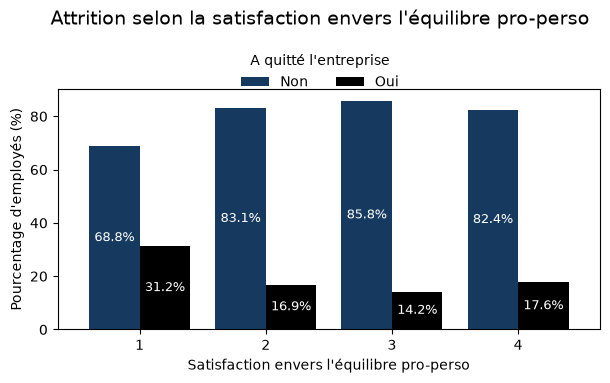

In [68]:
# Attrition selon la satisfaction envers l'équilibre vie professionnelle / vie personnelle

fig, ax = plt.subplots(figsize=(7, 4))

attrition_equilibre = pd.crosstab(
    df_central["satisfaction_employee_equilibre_pro_perso"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
) * 100

attrition_equilibre.plot(
    kind="bar",
    ax=ax,
    color=["#163A5F", "#000000"],
    width=0.8
)

# Titre principal
fig.suptitle(
    "Attrition selon la satisfaction envers l'équilibre pro-perso",
    fontsize=14,
    y=0.98
)

# Supprimer la légende du graphique
ax.get_legend().remove()

# Légende centrée dans l'espace blanc sous le titre
fig.legend(
    title="A quitté l'entreprise",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=2,
    frameon=False
)

ax.set_xlabel("Satisfaction envers l'équilibre pro-perso")
ax.set_ylabel("Pourcentage d'employés (%)")

plt.xticks(rotation=0)

# Ajouter les pourcentages dans les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontsize=9
    )

# Espace entre le titre, la légende et le graphique
plt.subplots_adjust(
    top=0.78,
    bottom=0.18
)

plt.show()

> - **Analyse :** Le taux d'attrition est nettement plus élevé chez les employés ayant un niveau de satisfaction de **1 envers l'équilibre entre vie professionnelle et vie personnelle (31,2 %)**.

##### **Synthèse des variables qualitatives**

In [69]:
# Synthèse des variables qualitatives et de leur relation avec l'attrition

synthese_qualitatives = pd.DataFrame({
    "Variable": [
        "Heures supplémentaires",
        "Fréquence des déplacements",
        "Poste",
        "Satisfaction envers l'environnement",
        "Satisfaction envers la nature du travail",
        "Satisfaction envers l'équipe",
        "Satisfaction envers l'équilibre pro-perso",
        "Statut marital",
        "Département",
        "Genre",
        "Niveau d'éducation"
    ],

    "Comparaison observée": [
        "30,5 % avec heures supplémentaires vs 10,4 % sans",
        "24,9 % les déplacements fréquents vs 8,0 % sans déplacement",
        "39,8 % chez les Rep. Commercial vs 2,5 % les Dir Technique",
        "25,4 % au niveau 1 vs 13,5 % au niveau 4",
        "22,8 % au niveau 1 vs 11,3 % au niveau 4",
        "20,7 % au niveau 1 vs 14,8 % au niveau 4",
        "31,2 % au niveau 1 vs 14,2 % au niveau 3",
        "25,5 % chez les célib et 12,5 % chez les mariés",
        "20,6 % Commercial vs 13,8 % Consulting vs 19,0 % RH",
        "17,0 % hommes vs 14,8 % femmes",
        "18,2 % au niveau 1 vs 10,4 % au niveau 5"
    ],

    "Relation probable avec l'attrition": [
        "Forte",
        "Forte",
        "Forte",
        "Forte",
        "Modérée",
        "Modérée",
        "Modérée",
        "Modérée",
        "Faible",
        "Faible",
        "Faible"
    ]
})

# Trier selon le niveau de relation
ordre_relation = {
    "Forte": 1,
    "Modérée": 2,
    "Faible": 3
}

synthese_qualitatives["ordre"] = (
    synthese_qualitatives["Relation probable avec l'attrition"]
    .map(ordre_relation)
)

synthese_qualitatives = (
    synthese_qualitatives
    .sort_values("ordre")
    .drop(columns="ordre")
    .reset_index(drop=True)
)

synthese_qualitatives

,Variable,Comparaison observée,Relation probable avec l'attrition
0,Heures supplémentaires,"30,5 % avec heures supplémentaires vs 10,4 % sans",Forte
1,Fréquence des déplacements,"24,9 % les déplacements fréquents vs 8,0 % san...",Forte
2,Poste,"39,8 % chez les Rep. Commercial vs 2,5 % les D...",Forte
3,Satisfaction envers l'environnement,"25,4 % au niveau 1 vs 13,5 % au niveau 4",Forte
4,Satisfaction envers la nature du travail,"22,8 % au niveau 1 vs 11,3 % au niveau 4",Modérée
5,Satisfaction envers l'équipe,"20,7 % au niveau 1 vs 14,8 % au niveau 4",Modérée
6,Satisfaction envers l'équilibre pro-perso,"31,2 % au niveau 1 vs 14,2 % au niveau 3",Modérée
7,Statut marital,"25,5 % chez les célib et 12,5 % chez les mariés",Modérée
8,Département,"20,6 % Commercial vs 13,8 % Consulting vs 19,0...",Faible
9,Genre,"17,0 % hommes vs 14,8 % femmes",Faible


### **Analyse quantitative**

##### **Distribution de l'âge selon l'attrition**

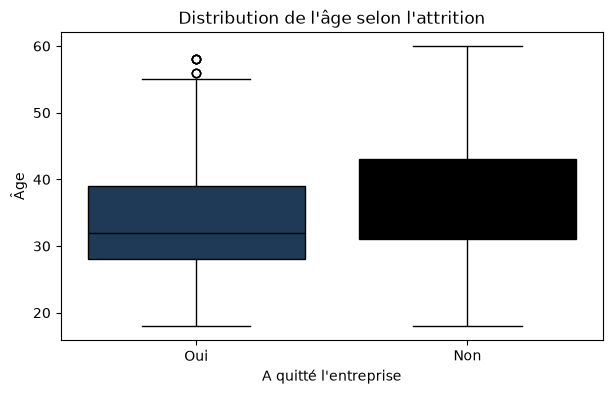

In [70]:
# Distribution de l'âge selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="age",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False
)

plt.title("Distribution de l'âge selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Âge")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent une **médiane d'âge plus faible**, autour de **32 ans**, contre environ **37 ans** chez les employés restés dans l'entreprise. Les distributions restent toutefois assez proches et présentent une forte zone de chevauchement. L'âge ne constitue pas à lui seul un facteur fortement discriminant.

##### **Distribution du revenu mensuel selon l'attrition**

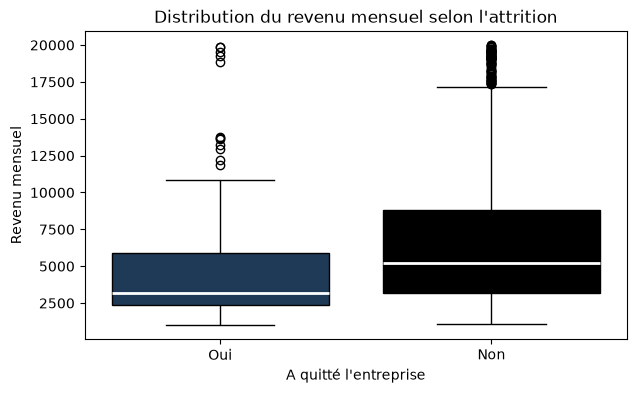

In [71]:
# distribution du revenu mensuel selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="revenu_mensuel",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution du revenu mensuel selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Revenu mensuel")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent un **revenu mensuel médian nettement inférieur** à celui des employés restés dans l'entreprise. La médiane se situe autour de **3 000–3 500 € chez les employés ayant quitté l'entreprise**, contre environ **6 000 € chez ceux restés**. Cette différence suggère une association entre un revenu mensuel plus faible et une attrition plus élevée.

##### **Distribution de l'expérience totale selon l'attrition**

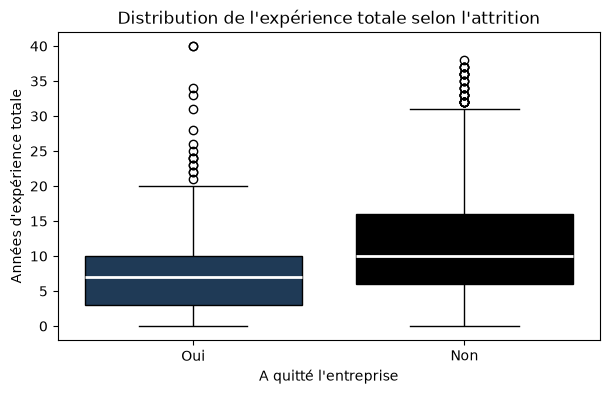

In [72]:
# Distribution de l'expérience totale selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="annee_experience_totale",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution de l'expérience totale selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Années d'expérience totale")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent une **expérience professionnelle totale médiane plus faible**, d'environ **7 ans**, contre environ **10 ans** chez les employés restés dans l'entreprise.

##### **Distribution de l'ancienneté dans l'entreprise selon l'attrition**

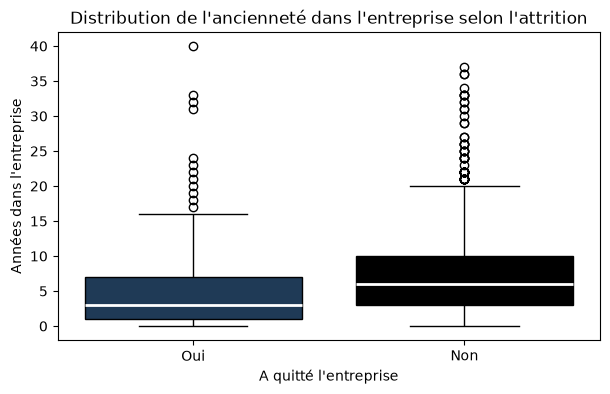

In [73]:
# Distribution de l'ancienneté dans l'entreprise selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="annees_dans_l_entreprise",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution de l'ancienneté dans l'entreprise selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Années dans l'entreprise")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent une **ancienneté médiane plus faible**, d'environ **3 ans**, contre environ **6 ans** chez les employés restés dans l'entreprise.

##### **Ancienneté dans le poste actuel selon l'attrition**

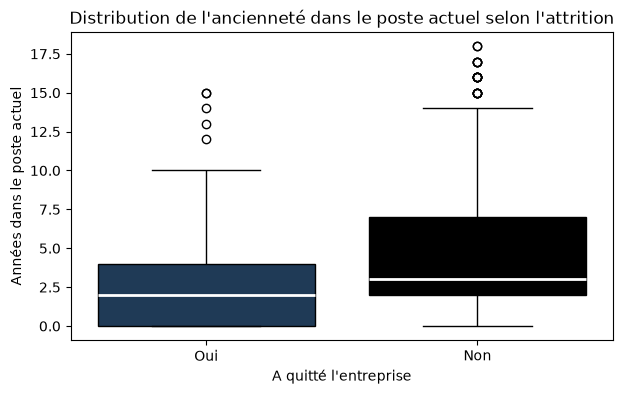

In [74]:
# Distribution de l'ancienneté dans le poste actuel selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="annees_dans_le_poste_actuel",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution de l'ancienneté dans le poste actuel selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Années dans le poste actuel")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent une **ancienneté médiane plus faible dans leur poste actuel**, d'environ **2 ans**, contre environ **3 ans** chez les employés restés dans l'entreprise. Les distributions se chevauchent toutefois largement. Cette variable semble donc présenter une **association modérée à faible avec l'attrition**.

##### **Nombre d'expériences précédentes selon l'attrition**

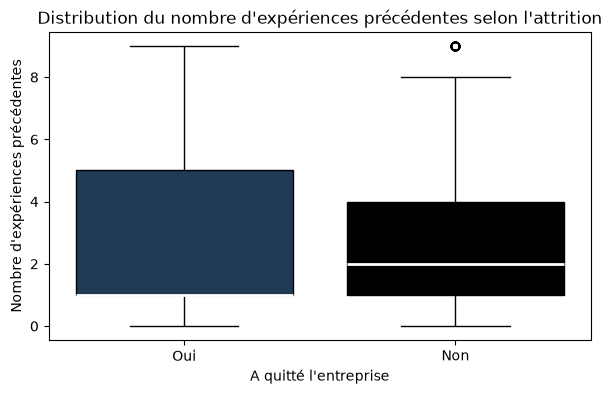

In [75]:
# Distribution du nombre d'expériences précédentes selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="nombre_experiences_precedentes",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution du nombre d'expériences précédentes selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Nombre d'expériences précédentes")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise tendent à avoir **moins d'expériences professionnelles précédentes**.

##### **Distribution de la participation au PEE selon l'attritionn**

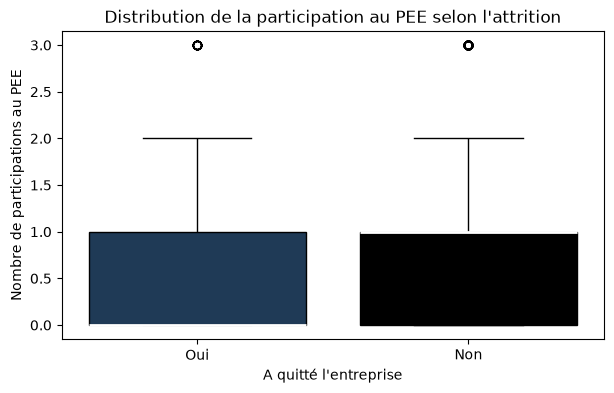

In [76]:
# Distribution de la participation au PEE selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="nombre_participation_pee",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution de la participation au PEE selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Nombre de participations au PEE")

plt.show()

> - **Analyse :** La participation au PEE présente une **distribution très similaire** entre les employés ayant quitté l'entreprise et ceux restés. Cette variable ne semble donc pas être fortement associée à l'attrition.

##### **Distribution du nombre de formations suivies selon l'attrition**

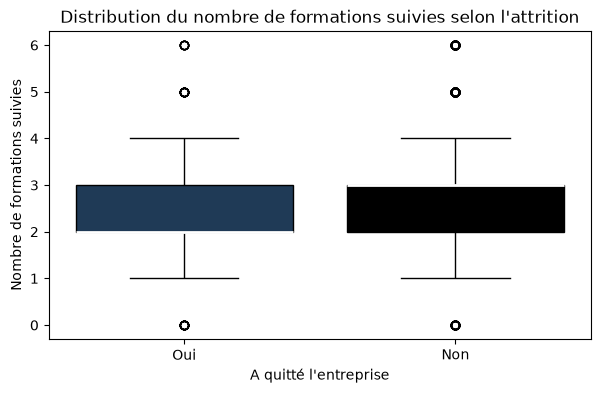

In [77]:
# Distribution du nombre de formations suivies selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="nb_formations_suivies",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution du nombre de formations suivies selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Nombre de formations suivies")

plt.show()

> - **Analyse :** Le nombre de formations suivies présente une **distribution très similaire** entre les deux groupes. Cette variable ne semble donc pas constituer un facteur fortement discriminant de l'attrition.

##### **Distribution de la distance domicile-travail selon l'attrition**

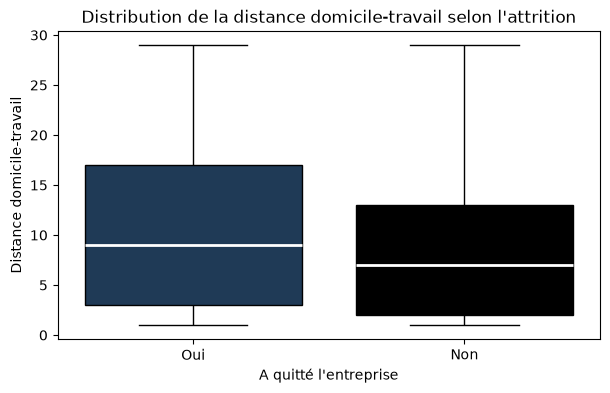

In [78]:
# Distribution de la distance domicile-travail selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="distance_domicile_travail",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution de la distance domicile-travail selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Distance domicile-travail")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent une **distance médiane domicile-travail plus élevée**, d'environ **9 km**, contre environ **7 km** chez les employés restés. Cette variable semble donc présenter une **association avec l'attrition**, les employés ayant une distance domicile-travail plus importante étant davantage concernés par les départs.

##### **Distribution des années depuis la dernière promotion selon l'attrition**

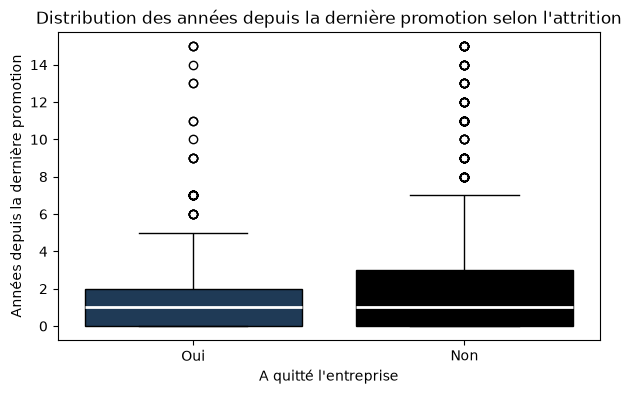

In [79]:
# Distribution des années depuis la dernière promotion selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="annees_depuis_la_derniere_promotion",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution des années depuis la dernière promotion selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Années depuis la dernière promotion")

plt.show()

> - **Analyse :** Le nombre d'années depuis la dernière promotion présente une **médiane similaire**, d'environ **1 an**, dans les deux groupes. Cette variable ne semble donc pas être fortement associée à l'attrition.

##### **Distribution des années sous le responsable actuel selon l'attrition**

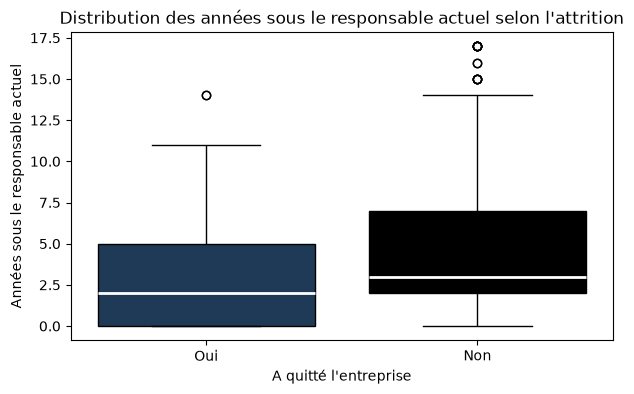

In [80]:
# Distribution des années sous le responsable actuel selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="annes_sous_responsable_actuel",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution des années sous le responsable actuel selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Années sous le responsable actuel")

plt.show()

> - **Analyse :** Les employés ayant quitté l'entreprise présentent une **ancienneté médiane plus faible sous leur responsable actuel**, d'environ **2 ans**, contre environ **3 ans** chez les employés restés. Cette différence suggère une **association faible à modérée** avec l'attrition.

##### **Distribution de l'augmentation salariale précédente selon l'attrition**

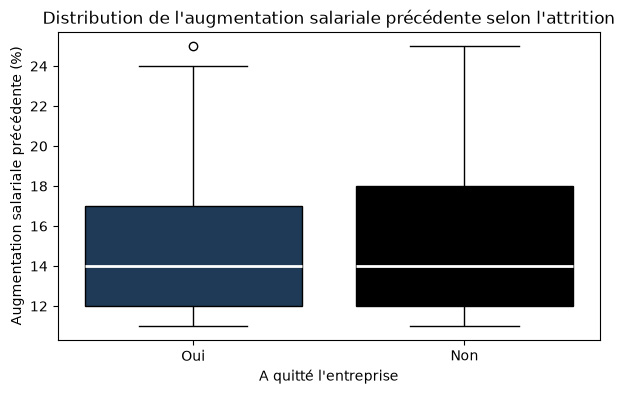

In [81]:
# Distribution de l'augmentation salariale précédente selon l'attrition

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_central,
    x="a_quitte_l_entreprise",
    y="augementation_salaire_precedente",
    hue="a_quitte_l_entreprise",
    palette=["#163A5F", "#000000"],
    legend=False,
    medianprops={"color": "white", "linewidth": 2}
)

plt.title("Distribution de l'augmentation salariale précédente selon l'attrition")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Augmentation salariale précédente (%)")

plt.show()

> - **Analyse :** L'augmentation salariale précédente présente une **médiane similaire d'environ 14 %** chez les employés ayant quitté l'entreprise et ceux restés. Cette variable semble donc avoir une **faible association avec l'attrition**.

##### **Synthèse des variables quantitatives**

In [82]:
# Synthèse des variables quantitatives et de leur relation avec l'attrition

synthese_quantitatives = pd.DataFrame({
    "Variable": [
        "Revenu mensuel",
        "Ancienneté dans l'entreprise",
        "Âge",
        "Expérience totale",
        "Distance domicile-travail",
        "Ancienneté dans le poste actuel",
        "Années sous le responsable actuel",
        "Nombre d'expériences précédentes",
        "Nombre de participations au PEE",
        "Nombre de formations suivies",
        "Années depuis la dernière promotion",
        "Augmentation salariale précédente"
    ],

    "Comparaison observée": [
        "Médiane plus faible chez les employés ayant quitté l'entreprise",
        "Environ 3 ans vs 6 ans chez ceux restés",
        "Environ 32 ans vs 37 ans chez ceux restés",
        "Environ 7 ans vs 10 ans chez ceux restés",
        "Environ 9 km vs 7 km chez ceux restés",
        "Environ 2 ans vs 3 ans chez ceux restés",
        "Environ 2 ans vs 3 ans chez ceux restés",
        "Environ 1 expérience vs 2 chez ceux restés",
        "Distribution très similaire entre les deux groupes",
        "Distribution très similaire entre les deux groupes",
        "Médiane similaire, autour de 1 an, dans les deux groupes",
        "Médiane similaire, autour de 14 % dans les deux groupes"
    ],

    "Relation probable avec l'attrition": [
        "Forte",
        "Forte",
        "Modérée",
        "Modérée",
        "Modérée",
        "Modérée",
        "Modérée",
        "Faible",
        "Faible",
        "Faible",
        "Faible",
        "Faible"
    ]
})

# Trier selon le niveau de relation
ordre_relation = {
    "Forte": 1,
    "Modérée": 2,
    "Faible": 3
}

synthese_quantitatives["ordre"] = (
    synthese_quantitatives["Relation probable avec l'attrition"]
    .map(ordre_relation)
)

synthese_quantitatives = (
    synthese_quantitatives
    .sort_values("ordre")
    .drop(columns="ordre")
    .reset_index(drop=True)
)

synthese_quantitatives

,Variable,Comparaison observée,Relation probable avec l'attrition
0,Revenu mensuel,Médiane plus faible chez les employés ayant qu...,Forte
1,Ancienneté dans l'entreprise,Environ 3 ans vs 6 ans chez ceux restés,Forte
2,Âge,Environ 32 ans vs 37 ans chez ceux restés,Modérée
3,Expérience totale,Environ 7 ans vs 10 ans chez ceux restés,Modérée
4,Distance domicile-travail,Environ 9 km vs 7 km chez ceux restés,Modérée
5,Ancienneté dans le poste actuel,Environ 2 ans vs 3 ans chez ceux restés,Modérée
6,Années sous le responsable actuel,Environ 2 ans vs 3 ans chez ceux restés,Modérée
7,Nombre d'expériences précédentes,Environ 1 expérience vs 2 chez ceux restés,Faible
8,Nombre de participations au PEE,Distribution très similaire entre les deux gro...,Faible
9,Nombre de formations suivies,Distribution très similaire entre les deux gro...,Faible


### **Insights principaux**

> - **Risque élevé :** les heures supplémentaires, les déplacements fréquents et certains postes, notamment les Représentants Commercial, sont associés à une attrition plus élevée.
>
> - **Satisfaction :** une faible satisfaction concernant l'environnement, la nature du travail et surtout l'équilibre pro-perso est associée à davantage de départs.
>
> - **Profil des départs :** les employés ayant un revenu plus faible, une ancienneté plus courte et une expérience professionnelle plus limitée semblent davantage concernés par l'attrition.
>
> - **Points moins discriminants :** le genre, le nombre de formations, la participation au PEE et les années depuis la dernière promotion montrent peu de différences entre les deux groupes.
>
> - **À retenir :** ces résultats mettent en évidence des **associations** avec l'attrition et serviront de base à la phase de modélisation pour identifier les facteurs les plus prédictifs.

## **Sauvegarde du jeu de données**

In [ ]:
df_central.to_csv(
    "../data/processed/df_central.csv",
    index=False
)